# Name : Methu Paroi
# Roll : 21053294
# Sec : CSE-09
# Date : 25.03.24

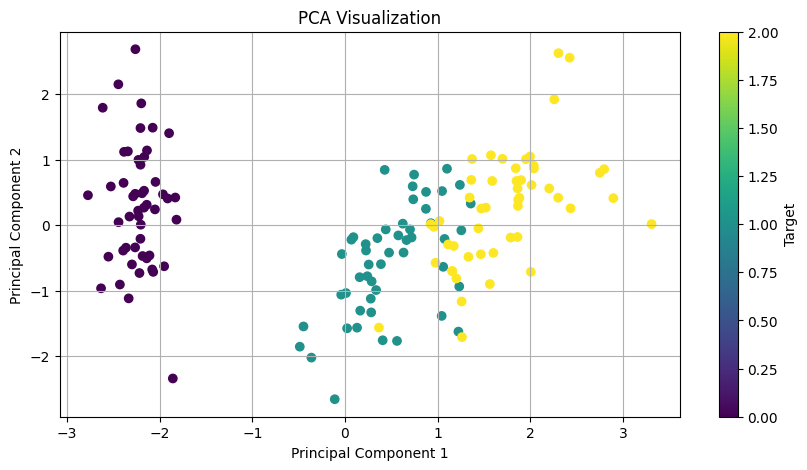

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as sklearnPCA
import matplotlib.pyplot as plt

# Step 1: Load and Preprocess the Dataset
data = load_iris()
X = data.data
y = data.target

# Preprocessing: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame (optional)
df = pd.DataFrame(X_scaled, columns=data.feature_names)
df['target'] = y

# Save preprocessed data to CSV (optional)
df.to_csv('iris_preprocessed.csv', index=False)

# Step 2: Implement PCA from Scratch
def PCA(X, n_components):
    # Compute covariance matrix
    cov_matrix = np.cov(X, rowvar=False)
    
    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Sort eigenvalues and eigenvectors
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # Select top k eigenvectors
    components = eigenvectors[:, :n_components]
    
    # Project data onto selected components
    projected_data = np.dot(X, components)
    
    return projected_data

# Apply PCA
n_components = 2
X_pca_scratch = PCA(X_scaled, n_components)

# Save PCA result to CSV (optional)
np.savetxt('iris_pca_scratch.csv', X_pca_scratch, delimiter=',')

# Step 3: Apply PCA Using scikit-learn
pca = sklearnPCA(n_components=n_components)
X_pca_sklearn = pca.fit_transform(X_scaled)

# Save PCA result to CSV (optional)
np.savetxt('iris_pca_sklearn.csv', X_pca_sklearn, delimiter=',')

# Step 4: Visualize the Results of PCA
plt.figure(figsize=(10, 5))
plt.scatter(X_pca_sklearn[:, 0], X_pca_sklearn[:, 1], c=y, cmap='viridis')
plt.title('PCA Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Target')
plt.grid(True)
plt.show()


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 5: Logistic Regression on Original Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize logistic regression model
logreg_original = LogisticRegression()

# Train the model
logreg_original.fit(X_train, y_train)

# Predictions on test set
y_pred_original = logreg_original.predict(X_test)

# Calculate accuracy
accuracy_original = accuracy_score(y_test, y_pred_original)
print("Accuracy on original data:", accuracy_original)


Accuracy on original data: 1.0


In [5]:
# Step 6: Logistic Regression on PCA Data
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(X_pca_sklearn, y, test_size=0.2, random_state=42)

# Initialize logistic regression model
logreg_pca = LogisticRegression()

# Train the model
logreg_pca.fit(X_pca_train, y_pca_train)

# Predictions on test set
y_pred_pca = logreg_pca.predict(X_pca_test)

# Calculate accuracy
accuracy_pca = accuracy_score(y_pca_test, y_pred_pca)
print("Accuracy after PCA:", accuracy_pca)


Accuracy after PCA: 0.9
